DT CV MEAN 0.7037913501977278
DT CV STD 0.048084237421269
RF CV MEAN 0.7318561295587219
RF CV STD 0.05307128600399728
LOGISTIC REGRESSION CV MEAN 0.6947837549431924
LOGISTIC REGRESSION CV STD 0.030610241729548463
{'max_depth': 4, 'min_samples_split': 2}
0.7078203486654191
{'max_depth': 3, 'n_estimators': 100}
0.7274598640795824
TEST ACCURACY 0.7430167597765364
CV SCORE: 0.7274598640795824
gap 0.015556895696953954


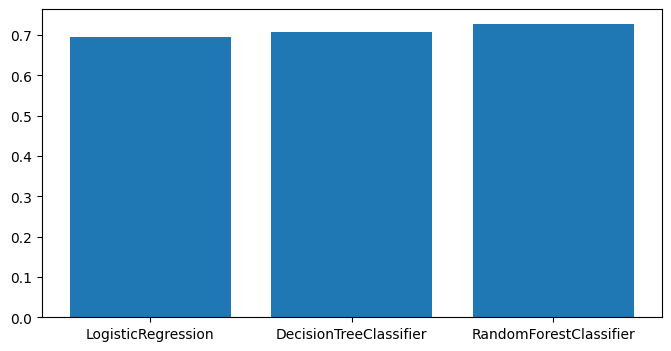

In [ ]:
# Use Titanic data — same cleaning
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score,GridSearchCV,train_test_split
df=pd.read_csv('train.csv')
df['Age']=df['Age'].fillna(df['Age'].median())
df=df.drop('Cabin',axis=1)
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
X=df[['Age','Fare','Parch','Pclass','SibSp']]
Y=df['Survived']
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
# 1. Run cross_val_score on these 3 models with cv=5:
#    - DecisionTree max_depth=3
#    - RandomForest n_estimators=100, max_depth=5
#    - LogisticRegression
#    Print mean AND std for each
#    Which model is most stable? (lowest std)
dt=DecisionTreeClassifier(max_depth=3,random_state=42)
dt_scores=cross_val_score(dt,X,Y,cv=5)
print('DT CV MEAN',dt_scores.mean())
print('DT CV STD',dt_scores.std())
rf=RandomForestClassifier(n_estimators=100,max_depth=5,random_state=42)
rf_scores=cross_val_score(rf,X,Y,cv=5)
print('RF CV MEAN',rf_scores.mean())
print('RF CV STD',rf_scores.std())
lr=LogisticRegression()
lr_score=cross_val_score(lr,X,Y,cv=5)
print('LOGISTIC REGRESSION CV MEAN',lr_score.mean())
print('LOGISTIC REGRESSION CV STD',lr_score.std())
#DT IS STABLE AS ITS STD IS LOW

# 2. GridSearchCV on DecisionTree:
#    param_grid:
#    max_depth: [2, 3, 4, 5]
#    min_samples_split: [2, 5, 10]
#    cv=5, scoring='accuracy'
#    Print best_params_ and best_score_
param={
    'max_depth':[2,3,4,5],
    'min_samples_split':[2,5,10]
}
dgs=GridSearchCV(DecisionTreeClassifier(random_state=42),param,cv=5,scoring='accuracy')
dgs.fit(X_train,Y_train)
print(dgs.best_params_)
print(dgs.best_score_)

# 3. GridSearchCV on RandomForest:
#    param_grid:
#    n_estimators: [50, 100]
#    max_depth: [3, 5]
#    cv=5
#    Print best_params_ and best_score_
#    Use best_estimator_ to predict on X_test
#    Print final test accuracy
param1={
    'n_estimators':[50,100],
    'max_depth':[3,5]
}
rgs=GridSearchCV(RandomForestClassifier(random_state=42),param1,cv=5)
rgs.fit(X_train,Y_train)
print(rgs.best_params_)
print(rgs.best_score_)
# 4. Compare CV scores vs test accuracy for best RF:
#    CV score: ?
#    Test score: ?
#    Gap: ?
#    Is the model trustworthy?
best=rgs.best_estimator_
print('TEST ACCURACY',best.score(X_test,Y_test))
print('CV SCORE:',rgs.best_score_)
print('gap',abs(rgs.best_score_-best.score(X_test,Y_test)))

# 5. Plot CV scores for all 3 models as bar chart
#    x = model names
#    y = mean CV score
#    Add error bars using std:
#    plt.bar(models, means, yerr=stds)
plt.figure(figsize=(8,4))
model_name=['LogisticRegression','DecisionTreeClassifier','RandomForestClassifier']
CV=[lr_score.mean(),dt_scores.mean(),rf_scores.mean()]
STD = [lr_score.std(), dt_scores.std(), rf_scores.std()]
plt.bar(model_name,CV,yerr=STD)
plt.show()
